## Часть 1. Анализ 75% epiboly и 1–2 ss

По аналогии с семинаром

### 75% epiboly

1) Статистика

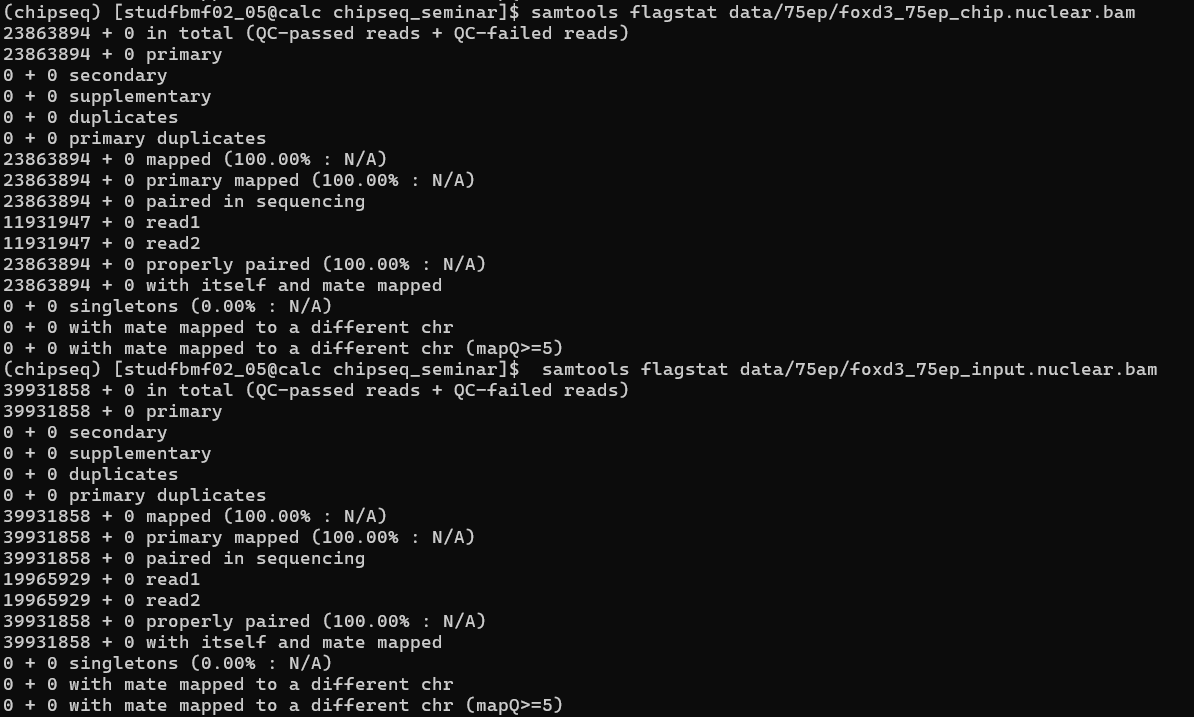

2) Через bamCoverage переводим риды ChIP/Input в сигнал

3) Далее для IGV считаем обогащение

4) Выявляем участки обогащения с помощью MACS3 (порог значимости = 0,01) + смотрим количество получившихся пиков:

In [ ]:
(chipseq) [studfbmf02_05@calc chipseq_seminar]$ wc -l results/75ep/peaks/foxd3_75ep_peaks.narrowPeak
36 results/75ep/peaks/foxd3_75ep_peaks.narrowPeak

5) Выведем самый значимый пик

In [ ]:
(chipseq) [studfbmf02_05@calc chipseq_seminar]$ sort -k9,9nr results/75ep/peaks/foxd3_75ep_peaks.narrowPeak | head -1
NC_007113.7     33276014        33276551        foxd3_75ep_peak_2       1000    .       21.7013 109.261 100.05 250

6) Рассчитаем FRiP

In [ ]:
(chipseq) [studfbmf02_05@calc chipseq_seminar]$  samtools view -c data/75ep/foxd3_75ep_chip.nuclear.bam
23863894
(chipseq) [studfbmf02_05@calc chipseq_seminar]$ samtools view -c \
  -L results/75ep/peaks/foxd3_75ep_peaks.narrowPeak \
  data/75ep/foxd3_75ep_chip.nuclear.bam
4101

FRiP = 4101/23863894 = 0,017%

7) Строим heatmap и average profile

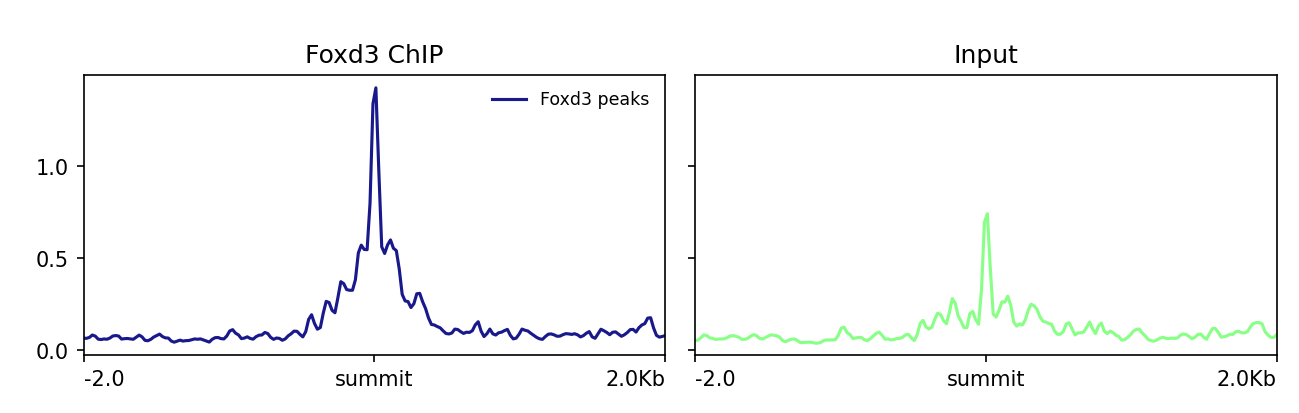

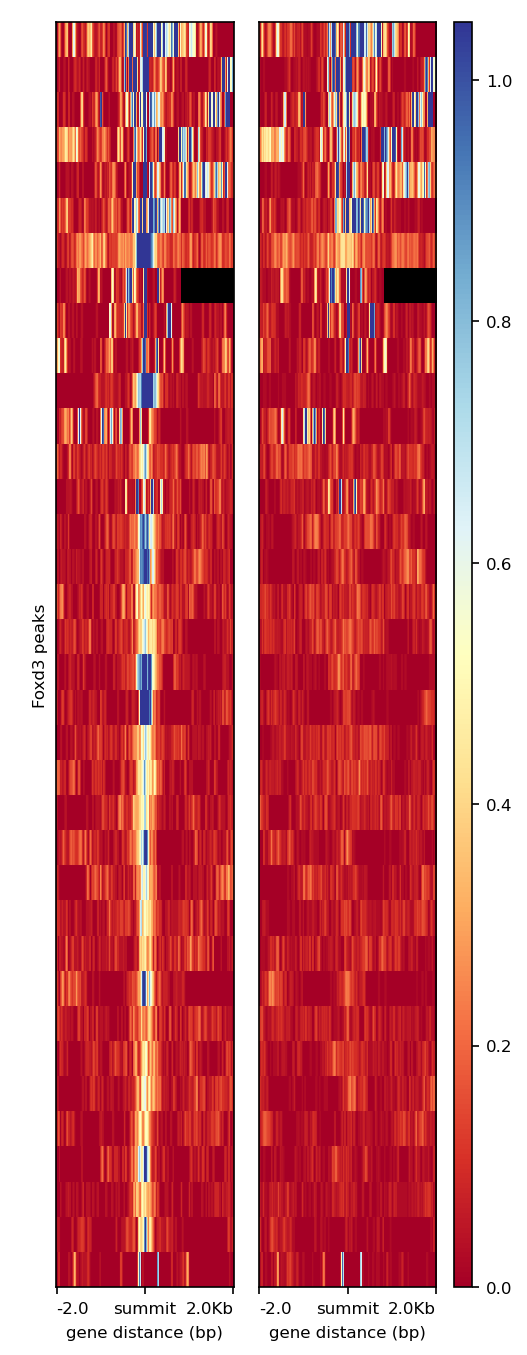

###1–2 ss

Проделываем все то же самое, что и для 75% epiboly

1) Статистика

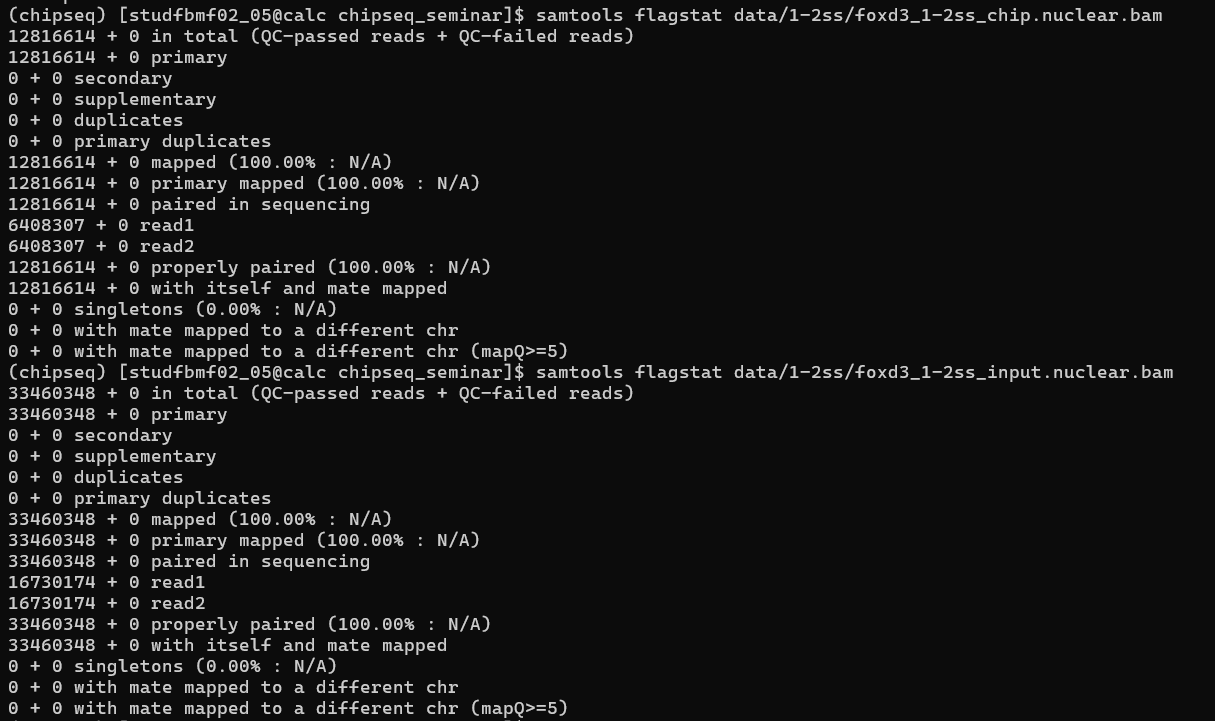

2) Смотрим количество пиков

In [ ]:
(chipseq) [studfbmf02_05@calc chipseq_seminar]$ wc -l results/1-2ss/peaks/foxd3_1-2ss_peaks.narrowPeak
40 results/1-2ss/peaks/foxd3_1-2ss_peaks.narrowPeak

3) Выводим самый значимый

In [ ]:
(chipseq) [studfbmf02_05@calc chipseq_seminar]$ sort -k9,9nr results/1-2ss/peaks/foxd3_1-2ss_peaks.narrowPeak | head -1
NC_007113.7     33276062        33276596        foxd3_1-2ss_peak_3      561     .       21.2286 65.2724 56.183  217

4) Рассчет FRiP

In [ ]:
(chipseq) [studfbmf02_05@calc chipseq_seminar]$ samtools view -c data/1-2ss/foxd3_1-2ss_chip.nuclear.bam
12816614
(chipseq) [studfbmf02_05@calc chipseq_seminar]$ samtools view -c \
  -L results/1-2ss/peaks/foxd3_1-2ss_peaks.narrowPeak \
  data/1-2ss/foxd3_1-2ss_chip.nuclear.bam
1799

FRiP = 1799/12816614 = 0,014 %

5) Строим heatmap и average profile

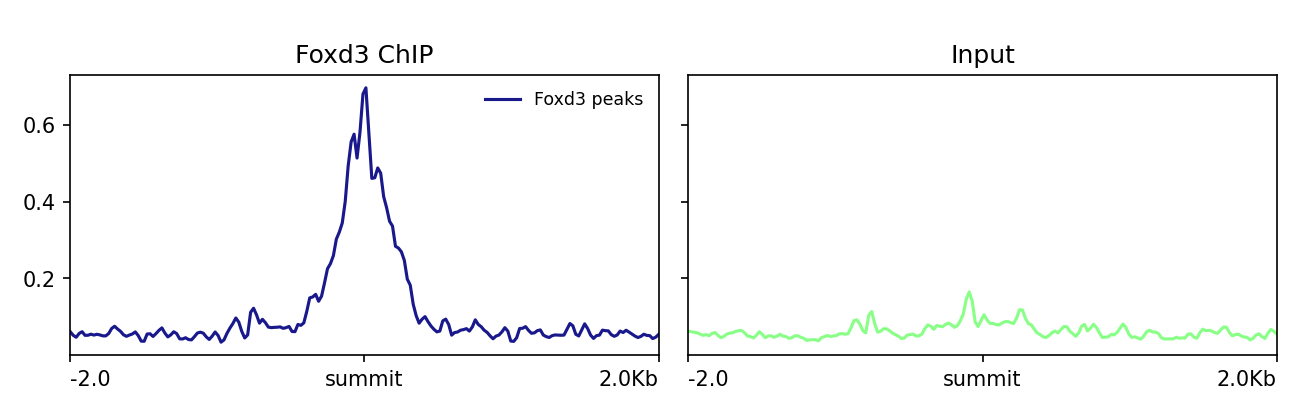

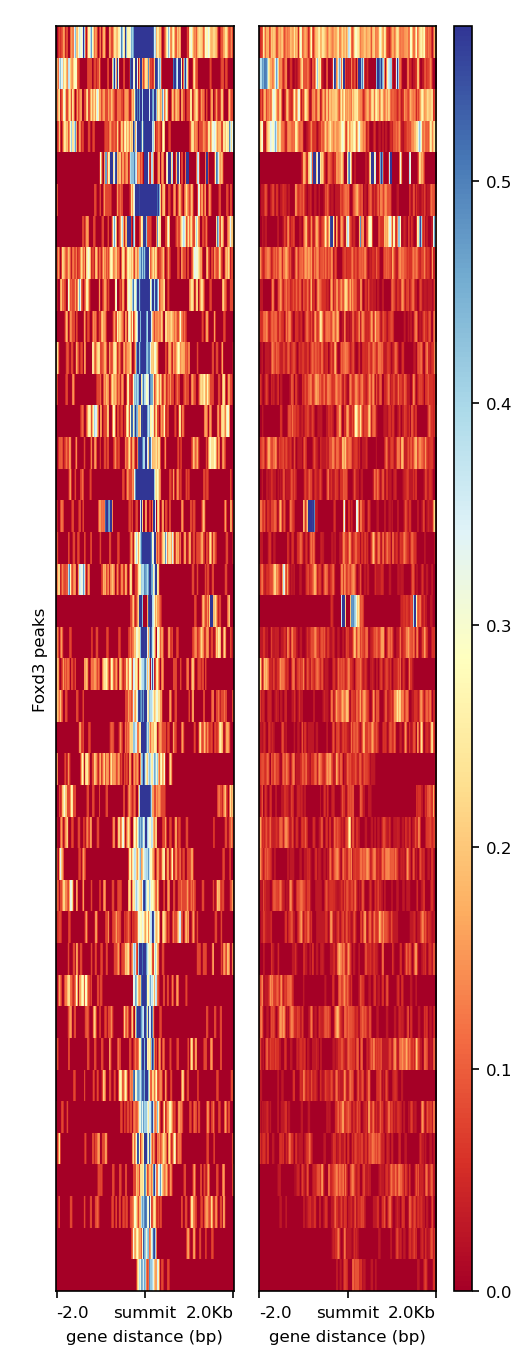

## Часть 2. Сводная таблица четырёх стадий

| Stage | ChIP alignments | Input alignments | Peaks | FRiP | max -log10(q) |
|-------|-----------------|------------------|-------|------|---------------|
| 75ep  | 23 863 894      | 39 931 858       | 36    | 0,00017 | 100,05     |
| 1-2ss | 12 816 614      | 33 460 348       | 40    | 0,00014 | 56,18      |
| 5-6ss | 18 853 396      | 57 051 062       | 839   | 0,00236 | 163,70     |
| 14ss  | 41 553 880      | 27 794 668       | 170   | 0,00162 | 321,45     |

* Больше всего пиков: 5–6ss - 839 пиков (в 20 раз превышает показатели ранних стадий)

* На какой стадии enrichment наиболее выражен?

    Смотрим на показатель FRiP (доля сигнала, сконцентрированная в пиках). Самый большой enrichment на стадии 5-6ss

* Можно ли объяснять разницу числа пиков только биологией?

    Нет. Число пиков является характеристикой конкретного эксперимента и параметров анализа, а не свойством исследуемого белка: оно зависит от глубины секвенирования, эффективности подготовки образца, доли целевых клеток в образце, порога FDR и наличия контроля

* Технические причины, влияющие на число пиков:

    Глубина секвенирования ChIP (статистическая мощность растёт с покрытием + при меньшей глубине слабые сайты не достигают порога значимости)

    Глубина Input (локальная лямбда оценивается по контролю в окнах 1 и 10 кб. Мелкий Input даёт шумную оценку фона, что снижает чувствительность)

    Порог FDR

    Параметры фрагментации


##Часть 3. Сравнение Foxd3 peaks между стадиями

Для bedtools jaccard отсорируем входные файлы по хромосоме и координате начала

In [ ]:
(chipseq) [studfbmf02_05@calc chipseq_seminar]$ mkdir -p results/stage_comparison/sorted
(chipseq) [studfbmf02_05@calc chipseq_seminar]$ D=results/stage_comparison/sorted
(chipseq) [studfbmf02_05@calc chipseq_seminar]$ sort -k1,1 -k2,2n results/75ep/peaks/foxd3_75ep_peaks.narrowPeak > $D/75ep.bed
(chipseq) [studfbmf02_05@calc chipseq_seminar]$ sort -k1,1 -k2,2n results/1-2ss/peaks/foxd3_1-2ss_peaks.narrowPeak > $D/1-2ss.bed
(chipseq) [studfbmf02_05@calc chipseq_seminar]$ sort -k1,1 -k2,2n teacher/foxd3_5-6ss_peaks.narrowPeak > $D/5-6ss.bed
(chipseq) [studfbmf02_05@calc chipseq_seminar]$ sort -k1,1 -k2,2n results/peaks/foxd3_14ss_peaks.narrowPeak > $D/14ss.bed
(chipseq) [studfbmf02_05@calc chipseq_seminar]$ wc -l $D/*.bed
   40 results/stage_comparison/sorted/1-2ss.bed
  170 results/stage_comparison/sorted/14ss.bed
  839 results/stage_comparison/sorted/5-6ss.bed
   36 results/stage_comparison/sorted/75ep.bed
 1085 total

Далее проведем 6 сравнений наборов пиков и результаты запишем в таблицу:

In [ ]:
#пример сравнения пиков на стадии 75ep и 1-2ss
(chipseq) [studfbmf02_05@calc chipseq_seminar]$ bedtools intersect -a $D/75ep.bed -b $D/1-2ss.bed -u | wc -l
12
(chipseq) [studfbmf02_05@calc chipseq_seminar]$ bedtools intersect -a $D/75ep.bed -b $D/1-2ss.bed -v | wc -l
24
(chipseq) [studfbmf02_05@calc chipseq_seminar]$ bedtools jaccard -a $D/75ep.bed -b $D/1-2ss.bed
intersection    union   jaccard n_intersections
3227    18577   0.173709        12

| # | A     | B     | Peaks A | Peaks B | A ∩ B | A-specific | Jaccard |
|---|-------|-------|---------|---------|-------|------------|---------|
| 1 | 75ep  | 1-2ss | 36      | 40      | 12    | 24         | 0,1737  |
| 2 | 75ep  | 5-6ss | 36      | 839     | 22    | 14         | 0,0227  |
| 3 | 75ep  | 14ss  | 36      | 170     | 18    | 18         | 0,0751  |
| 4 | 1-2ss | 5-6ss | 40      | 839     | 30    | 10         | 0,0281  |
| 5 | 1-2ss | 14ss  | 40      | 170     | 12    | 28         | 0,0426  |
| 6 | 5-6ss | 14ss  | 839     | 170     | 40    | 799        | 0,0369  |

* Какие стадии наиболее похожи по расположению Foxd3 peaks?

    Наиболее сходны 75% эпиболии и 1–2ss (индекс Жаккара для этой пары на порядок превышает значения для всех остальных пар)

* Какие наиболее различаются?

    Минимальный индекс получен для пар с участием 5–6ss (2 и 4 пары), но эти значения занижены, тк набор 5–6ss в 20 раз больше ранних.Я бы обратила внимание на пару 5–6ss/14ss - из 839 пиков 5–6ss лишь 40 (4,8%) выявляются на 14ss
*  Есть ли признаки сильной перестройки binding landscape?

    Да, динамика меняется. Сначала видим расширение репертуара от 75ep к 5–6ss (число пиков растет от 36 до 839, при этом ранние сайты в значительной мере сохраняются (61–75%)). Далее большая часть сайтов 5-6ss уже не выявляется на 14ss + примерно 3/4 пиков 14ss являются новыми

* Почему отсутствие вызванного peak на другой стадии ещё не доказывает
   отсутствие связывания Foxd3?

    Мы задаем пороговое q-value для MACS3, и отсутствие пика означает лишь то, что обогащение не достигло порога значимости в данном эксперименте. Сайт связывания может быть реальным, но находиться под порогом отбора

## Часть 4. Форматы файлов

| Формат | Что хранит | Text/Binary | Для чего использовали |
|--------|------------|-------------|-----------------------|
| FASTA | Нуклеотидные последовательности хромосом - референсный геном| Text | `reference/GRCz11.fa` - референс для IGV|
| GTF | Аннотация генома: координаты генов, транскриптов, экзонов и CDS | Text | `reference/GRCz11.gtf` - отображение генов в IGV для оценки положения пиков относительно генов |
| BAM | Выравнивания ридов на референс (позиция, CIGAR, MAPQ, флаги, качества оснований). Дискретные наблюдения — исходный уровень данных | Binary | Входные данные всех стадий; через `samtools flagstat` получаем статистику QC + входной формат для bamCoverage и MACS3 |
| BAI | Индекс к BAM: таблица соответствия геномных интервалов и смещений в файле (позволяет извлечь участок без чтения файла целиком) | Binary | Требуется для `samtools view -L`, bamCoverage и просмотра BAM в IGV |
| BigWig | Непрерывный числовой сигнал вдоль генома - одно значение на бин (показывает сколько фрагментов накрывает данный участок после нормировки на глубину библиотеки) Получен из BAM агрегацией покрытия по окнам| Binary | Входные данные для bigwigCompare и построения профилей + визуализация в IGV |
| BED | Геномные интервалы: хромосома, начало, конец + доп.параметры | Text |получаем `*_summits.bed` от MACS3 - вершины пиков + результаты `bedtools intersect` |
| narrowPeak | Дискретные области обогащения - результат статистического теста по сигналу относительно локального фона. Бинаризация непрерывного сигнала | Text | Результат MACS3 для каждой стадии; вход для FRiP, попарных сравнений и отображения пиков в IGV |
| MACS3 peaks.xls | Информация о пиках в табличной форме, дополненная шапкой с полным логом запуска | Text | Проверка параметров запуска MACS3 и сопоставимости настроек между стадиями |
| TSV | Таблица с разделителем-табуляцией (структура задаётся содержимым, а не форматом) | Text | `teacher/5-6ss/frip.tsv` - метрика FRiP; сводные таблицы результатов |
| deepTools matrix.gz | Трёхмерный массив "регионы_бины_образцы" (для каждого региона сохранены значения сигнала каждого трека в окне вокруг точки) | Binary | Промежуточный файл между computeMatrix и plotHeatmap/plotProfile |
| PDF | Итоговые графики | Binary | HeatMap и усреднённые профили|

## Часть 5. IGV

С помощью IGV-визуализации посмотрим на 3 случая

###1) Участок с хорошо выраженным Foxd3 peak на 5–6 ss.


Для нахождения этого локуса отсортируем пики по 7 колонке (fold enrichment)

In [ ]:
(chipseq) [studfbmf02_05@calc chipseq_seminar]$ sort -k7,7gr teacher/foxd3_5-6ss_peaks.narrowPeak | grep "^NC_" | head -5 | cut -f1-3,7,9
NC_007114.7     14914145        14914787        30.9796 135.713
NC_007117.7     32206483        32207024        21.1014 163.701
NC_007112.7     259734  260218  20.9834 63.047
NC_007115.7     24985693        24986067        20.5017 60.4707
NC_007113.7     33275999        33276609        20.3123 112.115

Координаты окна визуализации NC_007114.7: 14910000-14919000  

(для Input шкалы отключила autocsale и сделала интервал такой же как у chip от 0 до 13)

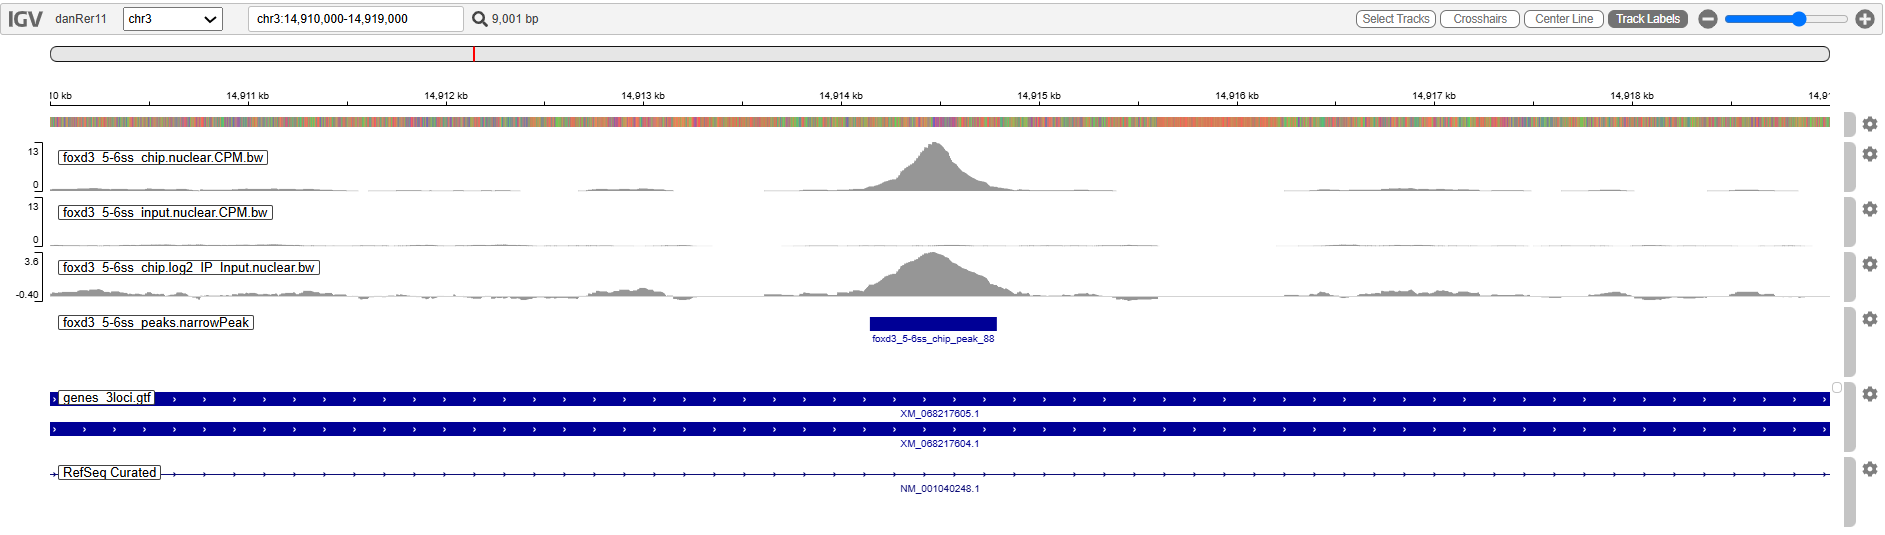

Видим, что сигнал Input в области пика не отличается от окружающего фона, что исключает объяснение обогащения различиями в доступности хроматина. Трек log2 принимает положительные значения только в области пика при значениях около нуля вне его, подтверждая специфичность обогащения.

###2) Участок, который имеет peak на нескольких стадиях


Раннее когда мы смотрели самые значимые пики для 75ep и 1-2ss - выводился NC_007113.7 с примерно одинаковыми координатами (75ep:33276014-33276551 / 1-2ss: 33276062-33276596). В семинаре я смотрела head foxd3_14ss_peaks.narrowPeak и там также был NC_007113.7 (33276096-33276465)

Делаем проверку наличия пика для 5-6ss в области 33276000-33276600

In [ ]:
(chipseq) [studfbmf02_05@calc chipseq_seminar]$  printf "NC_007113.7\t33276000\t33276600\n" > /tmp/locus.bed
(chipseq) [studfbmf02_05@calc chipseq_seminar]$  bedtools intersect -a teacher/foxd3_5-6ss_peaks.narrowPeak -b /tmp/locus.bed -u | cut -f1-3,7
NC_007113.7     33275999        33276609        20.3123

Координаты окна визуализации NC_007113.7: 33272000-33280000

(Шкалу log2 для всех сделала единой с интервалом от -0.5 до 3.5)

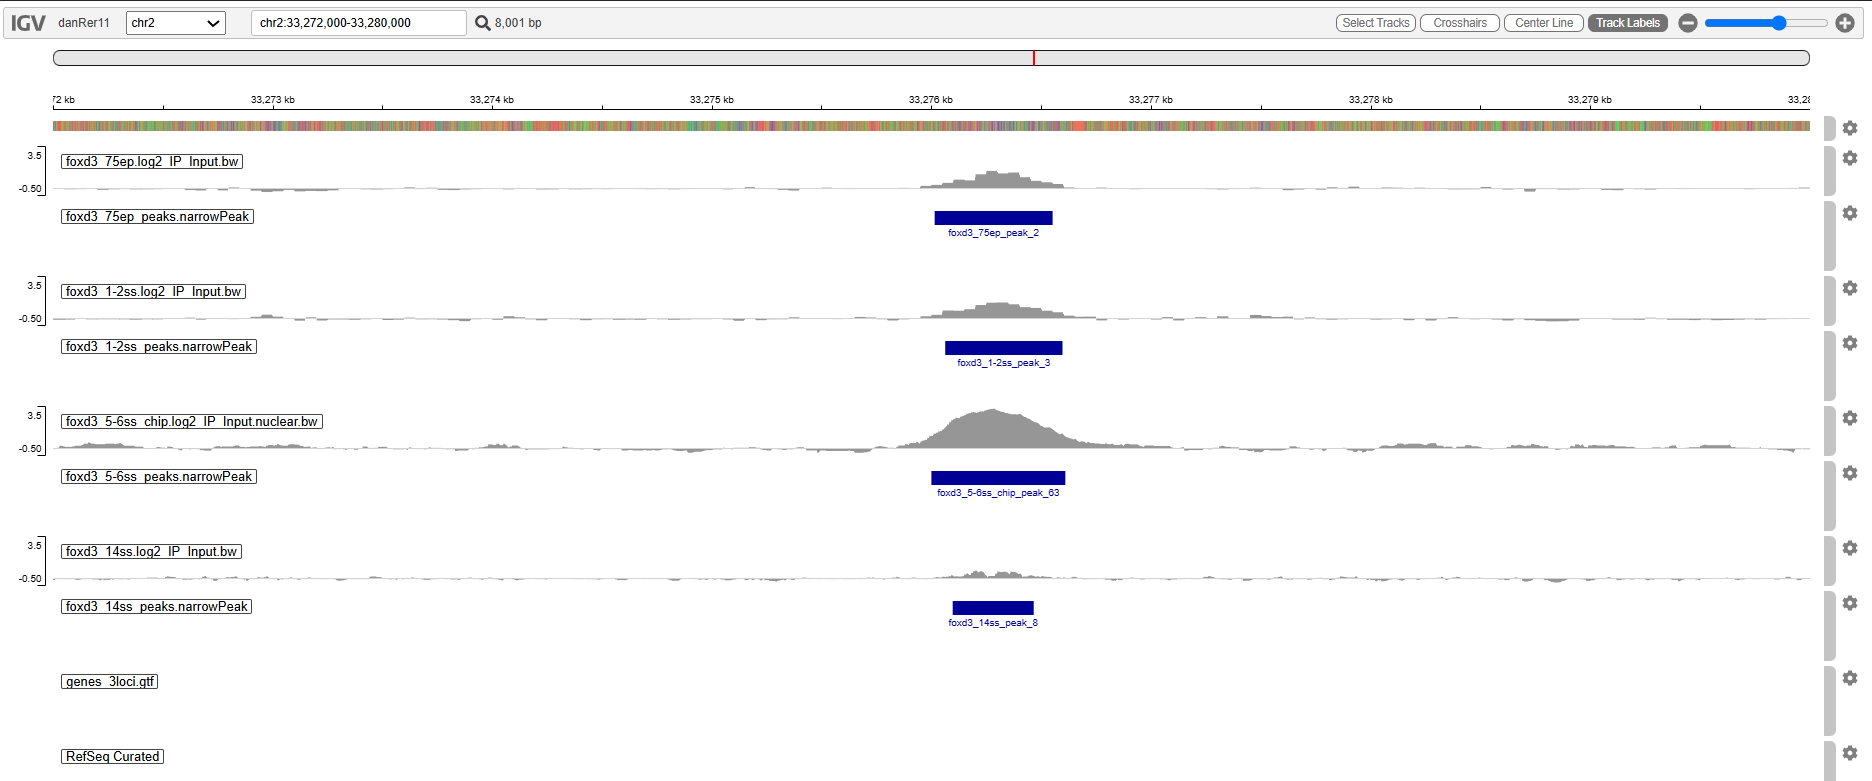

Сайт сохраняется на протяжении всего рассмотренного периода, но его занятость меняется, достигая максимума на стадии спецификации нервного гребня и минимума на миграторной стадии.

###3) Stage-specific и stage-biased region


Выведем список отсортированных по обогащению пиков 5-6ss которые не имеют пересечения с 14ss

In [ ]:
(chipseq) [studfbmf02_05@calc chipseq_seminar]$ D=results/stage_comparison/sorted
(chipseq) [studfbmf02_05@calc chipseq_seminar]$ bedtools intersect -a $D/5-6ss.bed -b $D/14ss.bed -v | grep "^NC_" | sort -k7,7gr | head -5 | cut -f1-3,7
NC_007112.7     259734  260218  20.9834
NC_007113.7     47424560        47425276        17.9566
NC_007123.7     8815692 8816156 15.8045
NC_007112.7     38815297        38815739        15.6433
NC_007128.7     27446917        27447336        14.318

Координаты окна визуализации NC_007112.7: 256000–264000

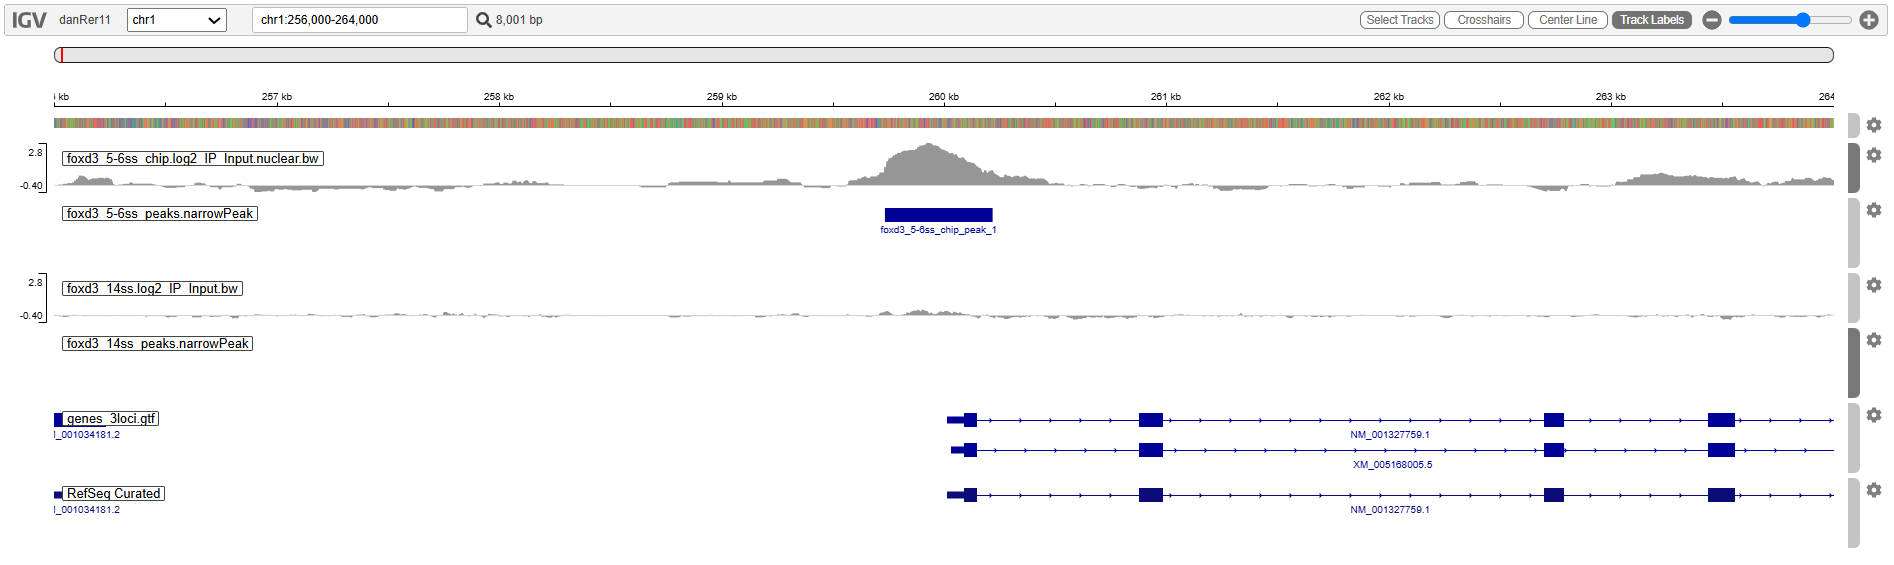

Оба трека log2 приведены к единой шкале (−0.40 до 2.8). При таком сопоставлении видно, что сигнал 14ss в области пика остаётся на уровне слабого локального подъёма (он всё же превышает окружающий фон)

Это говорит о том, что связывание Foxd3 в данном сайте на миграторной стадии не исчезает полностью, а ослабевает до уровня, не достигающего порога стат. значимости. Строго говоря, локус следует классифицировать как сильно stage-biased, а не как абсолютно стадие-специфичный (различие между этими категориями определяется порогом детекции, а не биологией)

## Часть 6. Биологическая интерпретация

1) Ландшафт связывания Foxd3 существенно меняется в ходе развития нервного гребня. Динамика складывается из двух фаз - от ранних стадий к 5–6ss репертуар расширяется, причём исходные сайты в значительной мере сохраняются (61% пиков 75ep и 75% пиков 1–2ss присутствуют на 5–6ss) - это соответствует описанной пионерной функции foxd3: на стадии спецификации он массово связывает регуляторные элементы генов нервного гребня, перестраивая хроматин и праймируя их к последующей активации

    От 5–6ss к 14ss репертуар замещается (это описывает переключение foxd3 с активаторной роли на репрессорную, которое , как написано в статье, реализуется через привлечение иных белков-партнёров)

    Индексы Жаккара также подтверждают низкое сходство между отдалёнными стадиями (0,023–0,075) при относительно высоком сходстве двух ранних стадий между собой (0,174)

2) Наиболее выраженный ChIP сигнал наблюдается на стадии 5-6ss. Здесь максимальны число пиков и FRiP (кстати результат согласуется с данными статьи, где на 5-6ss выявлено 2955 сайтов против 624, 531 и 658 на остальных стадиях)

3) Про стабильность сайтов: 40 сайтов сохраняются между 5–6ss и 14ss. Показательным примером является расмотренный в прошлой части локус chr2:33272000-33280000, в котором пик вызывается на всех четырёх стадиях

    Однако стабильность положения не означает стабильности занятости: fold enrichment в этом локусе составляет 21,70, 21,23, 20,31 и 5,53 для 75ep, 1–2ss, 5–6ss и 14ss соответственно. Сайт сохраняется, но эффективность связывания к миграторной стадии падает примерно вчетверо

    Я предполагаю, что такие постоянные сайты отоносятся к элементам ауторегуляции самого foxd3, либо это энхансеры генов поддержания мультипотентности, необходимые как в премиграторном, так и в миграторном гребне

4) Наличие/отсутствие пика означает недостижение порога значимости, а не отсутствие связывания. Мы это наблюдали на 3 скриншоте IGV-визуализации (трек log2 для 14ss все же демонстрировал слабый сигнал, то есть связывание сохраняется, но ослабевает)

5) ChIP-seq не определяет направление регуляции, он лишь показывает локализацию белка на ДНК. В нашей работе foxd3 в одном и том же организме на разных стадиях выполняет противоположные функции - праймирующую на 5–6ss и репрессорную на 14ss. По картам связывания это различие не видно и оно было установлено только с использованием доп.информации и сравнении с мутантом: изменение уровня экспресси постадийно (RNA-seq), доступность хроматина (ATAC-seq), активность энхансеров (H3K27ac ChIP-seq)